# Detecção de Anomalias em Transações em Python

Desafio do bootcamp Bradesco - GenAI, Dados & Cyber

## Objetivo

Este notebook implementa um fluxo de detecção de fraude em transações de cartão de crédito, considerando o forte desbalanceamento entre transações legítimas e fraudulentas. O foco da avaliação está especialmente em **Recall da classe fraude**, além de Precision, F1-score, ROC-AUC e curvas Precision-Recall. Também são utilizadas técnicas de balanceamento, ajuste de limiar de decisão e SHAP para interpretação das previsões.

## Dataset

In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# 2. Análise exploratória dos dados

Antes da modelagem, verificamos a estrutura do dataset, estatísticas básicas e a distribuição da variável-alvo.

A classe `1` representa uma transação fraudulenta e a classe `0` representa uma transação legítima.

In [3]:
print("Dimensões do dataset:", df.shape)
print("\nTipos e valores não nulos:")
df.info()

print("\nEstatísticas descritivas:")
display(df.describe())

print("\nDistribuição da variável Class:")
display(df["Class"].value_counts().rename(index={0: "Normal", 1: "Fraude"}))

print("\nDistribuição percentual:")
display(
    (df["Class"].value_counts(normalize=True) * 100)
    .rename(index={0: "Normal", 1: "Fraude"})
    .round(4)
)

Dimensões do dataset: (284807, 31)

Tipos e valores não nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Distribuição da variável Class:


,count
Class,
Normal,284315
Fraude,492



Distribuição percentual:


,proportion
Class,
Normal,99.8273
Fraude,0.1727


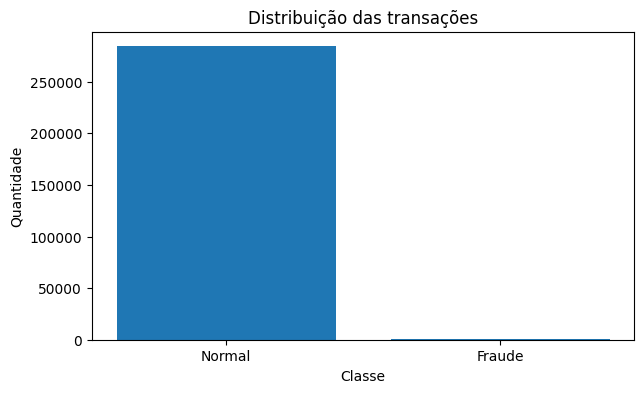

In [4]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(["Normal", "Fraude"], class_counts.values)
plt.title("Distribuição das transações")
plt.ylabel("Quantidade")
plt.xlabel("Classe")
plt.show()

### Interpretação

O dataset apresenta um forte desbalanceamento: a quantidade de transações legítimas é muito superior à quantidade de fraudes. Por isso, **accuracy isoladamente não é suficiente** para avaliar os modelos. Um classificador poderia obter uma accuracy elevada mesmo identificando poucas fraudes.

Neste problema, Recall da classe fraude é particularmente relevante porque mede a proporção das fraudes reais que foram identificadas pelo modelo.

# 3. Pré-processamento

In [5]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["Amount_log"] = np.log1p(df["Amount"])

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

Treino: (199364, 31)
Teste: (85443, 31)

Distribuição no treino:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64


A transformação `log1p` reduz a assimetria da variável `Amount` e cria a variável `Amount_log`. Neste notebook, as duas variáveis são mantidas para permitir que os modelos utilizem tanto o valor original quanto sua transformação logarítmica.

A divisão entre treino e teste utiliza `stratify=y`, preservando a proporção das classes nos dois conjuntos.

# 4. Baseline — Logistic Regression

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_lr = logistic_pipeline.predict(X_test)
y_probs_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



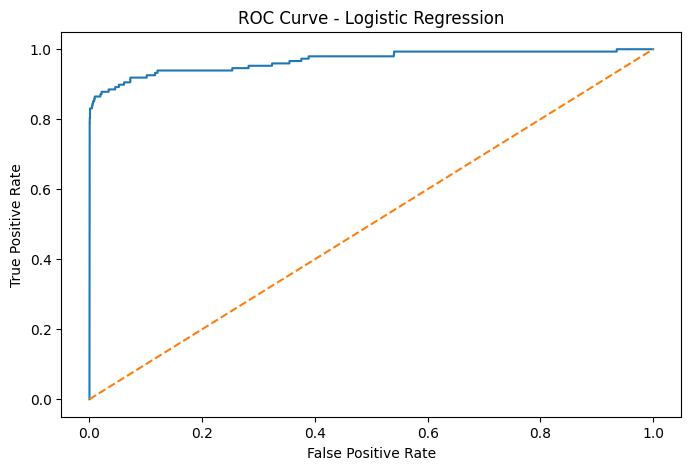

AUC: 0.9677917497777981


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs_lr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

auc_lr = roc_auc_score(y_test, y_probs_lr)

print("AUC:", auc_lr)

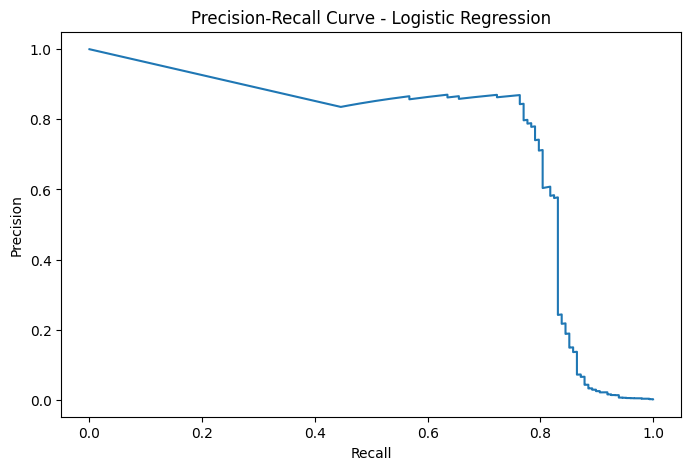

In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_probs_lr
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

## 4.1 Curva Precision-Recall

Em datasets muito desbalanceados, a curva Precision-Recall é especialmente útil porque evidencia o compromisso entre identificar mais fraudes e aumentar os falsos positivos.

# 5. Balanceamento — Undersampling

In [9]:
from sklearn.utils import resample

train_df = X_train.copy()
train_df["Class"] = y_train.values

fraudes_train = train_df[train_df["Class"] == 1]
normais_train = train_df[train_df["Class"] == 0]

normais_under = resample(
    normais_train,
    replace=False,
    n_samples=len(fraudes_train),
    random_state=42
)

train_under = pd.concat([fraudes_train, normais_under]).sample(
    frac=1,
    random_state=42
)

X_train_under = train_under.drop("Class", axis=1)
y_train_under = train_under["Class"]

print("Distribuição original do treino:")
print(y_train.value_counts())

print("\nDistribuição após undersampling:")
print(y_train_under.value_counts())

Distribuição original do treino:
Class
0    199020
1       344
Name: count, dtype: int64

Distribuição após undersampling:
Class
1    344
0    344
Name: count, dtype: int64


In [10]:
rf_under = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=None,
    n_jobs=-1,
    random_state=42
)

rf_under.fit(X_train_under, y_train_under)

y_pred_rf_under = rf_under.predict(X_test)
y_probs_rf_under = rf_under.predict_proba(X_test)[:, 1]

print("=== Random Forest com Undersampling ===")
print(classification_report(y_test, y_pred_rf_under))

=== Random Forest com Undersampling ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.86      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.56     85443
weighted avg       1.00      0.98      0.99     85443



# 6. Balanceamento — SMOTE

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribuição original do treino:")
print(y_train.value_counts())

print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())

Distribuição original do treino:
Class
0    199020
1       344
Name: count, dtype: int64

Distribuição após SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


In [12]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=None,
    n_jobs=-1,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)
y_probs_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest com SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote))

=== Random Forest com SMOTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.59      0.84      0.69       148

    accuracy                           1.00     85443
   macro avg       0.79      0.92      0.85     85443
weighted avg       1.00      1.00      1.00     85443



> O conjunto de teste permanece com a distribuição original das classes. O balanceamento é aplicado somente aos dados de treinamento, evitando vazamento de informação do teste para o processo de treinamento.

# 7. Random Forest — baseline com class weighting

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_probs_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



# 8. XGBoost

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=10,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.77      0.84       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



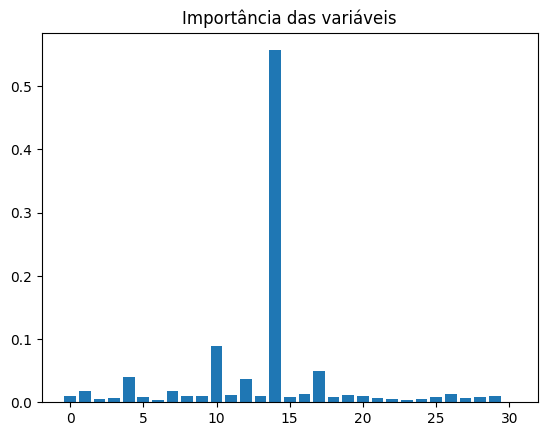

In [15]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()


# 9. Ajuste de hiperparâmetros — GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_probs_best = best_xgb.predict_proba(X_test)[:, 1]

print("=== Melhor XGBoost ===")
print(classification_report(y_test, y_pred_best))

auc_best = roc_auc_score(y_test, y_probs_best)

print("AUC:", auc_best)


Melhor modelo: {'max_depth': 5, 'n_estimators': 100}
=== Melhor XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.72      0.78       148

    accuracy                           1.00     85443
   macro avg       0.92      0.86      0.89     85443
weighted avg       1.00      1.00      1.00     85443

AUC: 0.9133524271090951


O `GridSearchCV` foi configurado com `scoring="recall"` para priorizar a identificação da classe fraude durante a validação cruzada. Os resultados no conjunto de teste são analisados separadamente, pois a escolha dos hiperparâmetros durante a validação não garante que o mesmo modelo terá o maior Recall no teste final.

# 10. Comparação dos modelos

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "XGBoost GridSearch"
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],
    "AUC": [
        roc_auc_score(y_test, y_probs_lr),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_probs_xgb),
        roc_auc_score(y_test, y_probs_best)
    ]
})

resultados

,Modelo,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.065491,0.878378,0.121894,0.967792
1,Random Forest,0.837037,0.763514,0.798587,0.959834
2,XGBoost,0.926829,0.770270,0.841328,0.975068
3,XGBoost GridSearch,0.835938,0.722973,0.775362,0.913352


In [18]:
from sklearn.metrics import average_precision_score

comparacao_extra = pd.DataFrame({
    "Modelo": [
        "Random Forest — Undersampling",
        "Random Forest — SMOTE",
        "Random Forest — class_weight"
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf_under, zero_division=0),
        precision_score(y_test, y_pred_rf_smote, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf_under, zero_division=0),
        recall_score(y_test, y_pred_rf_smote, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf_under, zero_division=0),
        f1_score(y_test, y_pred_rf_smote, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_probs_rf_under),
        roc_auc_score(y_test, y_probs_rf_smote),
        roc_auc_score(y_test, y_probs_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_probs_rf_under),
        average_precision_score(y_test, y_probs_rf_smote),
        average_precision_score(y_test, y_probs_rf)
    ]
})

display(comparacao_extra.sort_values("Recall", ascending=False))

,Modelo,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest — Undersampling,0.067196,0.858108,0.124632,0.975451,0.696047
1,Random Forest — SMOTE,0.587678,0.837838,0.690808,0.979210,0.759850
2,Random Forest — class_weight,0.837037,0.763514,0.798587,0.959834,0.780455


# 11. Curvas ROC

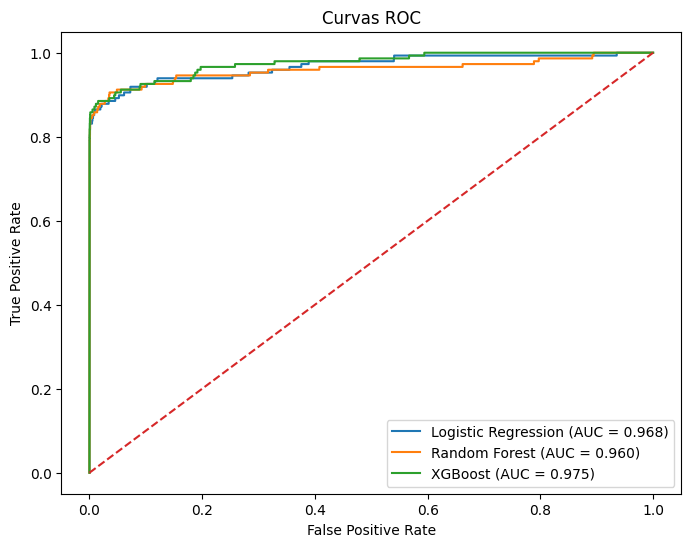

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

model_probs = {
    "Logistic Regression": y_probs_lr,
    "Random Forest": y_probs_rf,
    "XGBoost": y_probs_xgb
}

plt.figure(figsize=(8, 6))

for nome, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.show()

# 12. Curvas Precision-Recall

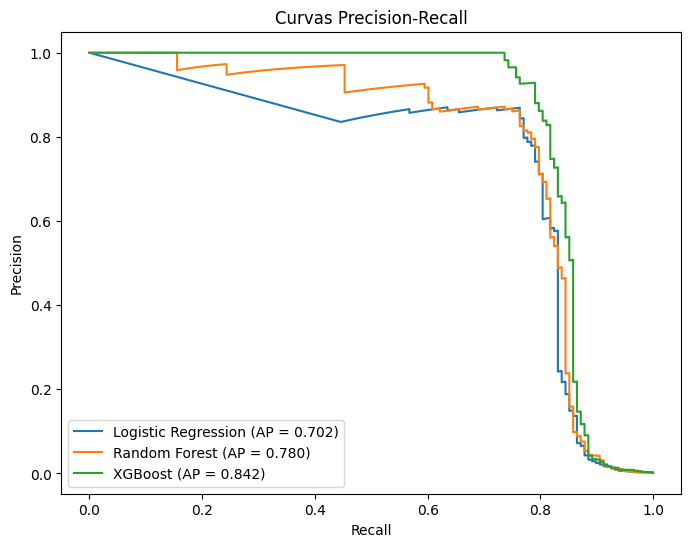

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for nome, probs in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{nome} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall")
plt.legend()
plt.show()

# 13. Ajuste do limiar de decisão

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds_to_test:
    pred = (y_probs_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,Threshold,Precision,Recall,F1-Score
0,0.10,0.856115,0.804054,0.829268
1,0.15,0.886364,0.790541,0.835714
2,0.20,0.900000,0.790541,0.841727
3,0.25,0.906977,0.790541,0.844765
4,0.30,0.914062,0.790541,0.847826
5,0.35,0.921260,0.790541,0.850909
6,0.40,0.926829,0.770270,0.841328
7,0.50,0.926829,0.770270,0.841328
8,0.60,0.933884,0.763514,0.840149
9,0.70,0.941176,0.756757,0.838951


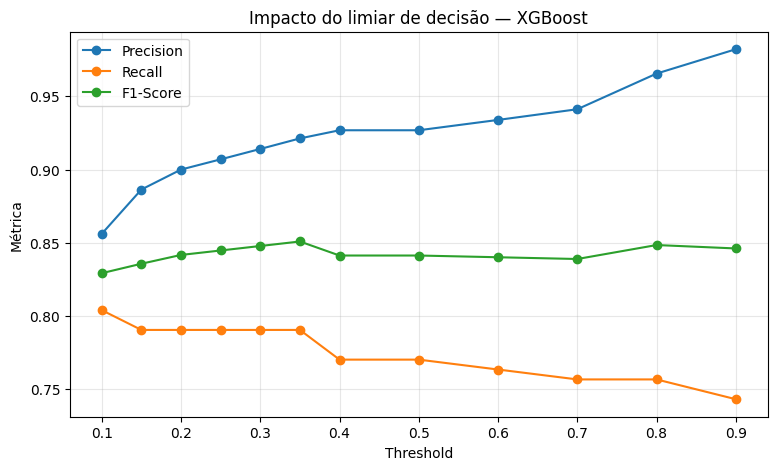

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Impacto do limiar de decisão — XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
# Escolha automática do threshold que maximiza o F1 no conjunto de teste.
# O valor encontrado deve ser interpretado como análise exploratória;
# para uma avaliação rigorosa, o threshold deveria ser escolhido em validação
# e somente depois aplicado ao conjunto de teste.
best_threshold_row = threshold_df.loc[threshold_df["F1-Score"].idxmax()]
best_threshold = float(best_threshold_row["Threshold"])

print(f"Threshold com maior F1 nesta análise: {best_threshold:.2f}")
display(best_threshold_row.to_frame().T)

y_pred_xgb_custom = (y_probs_xgb >= best_threshold).astype(int)

print("\n=== XGBoost com threshold ajustado ===")
print(classification_report(y_test, y_pred_xgb_custom))

Threshold com maior F1 nesta análise: 0.35


,Threshold,Precision,Recall,F1-Score
5,0.35,0.92126,0.790541,0.850909



=== XGBoost com threshold ajustado ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.92      0.79      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.90      0.93     85443
weighted avg       1.00      1.00      1.00     85443



### Interpretação do threshold

O threshold padrão de classificação é 0,50, mas ele pode ser alterado de acordo com o objetivo do sistema. Thresholds menores tendem a aumentar o Recall, porém podem aumentar a quantidade de falsos positivos. Thresholds maiores tendem a aumentar a Precision, mas podem deixar mais fraudes sem detecção.

Neste notebook, o threshold é comparado em vários valores e o resultado é usado para explicitar esse trade-off, em vez de escolher arbitrariamente um único valor.

# 14. Interpretabilidade com SHAP

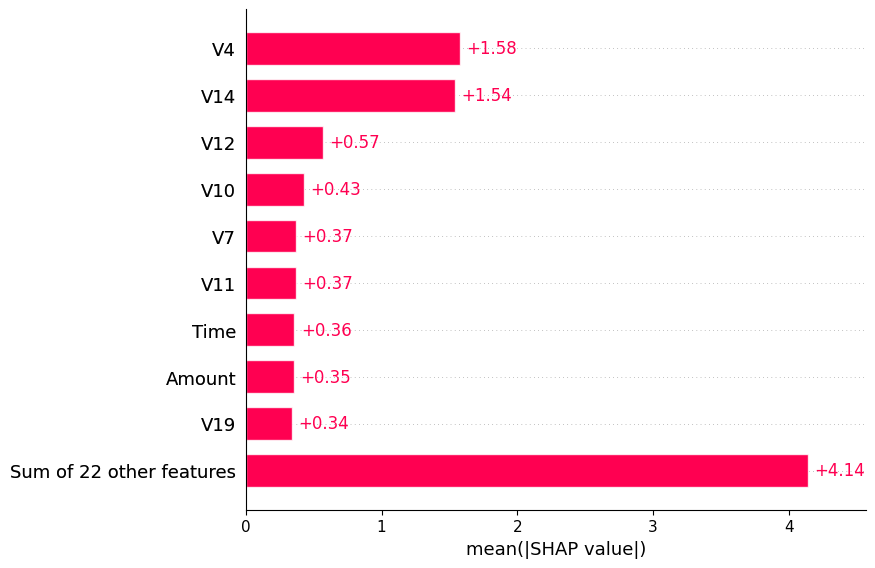

In [24]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

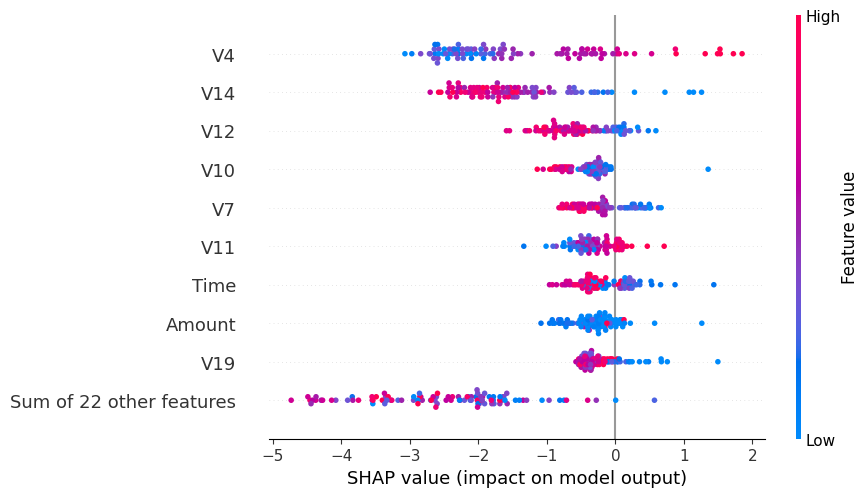

In [25]:
shap.plots.beeswarm(shap_values)

## 14.1 Explicação individual de uma transação

O gráfico abaixo mostra, para uma transação específica, quais características contribuíram para aumentar ou diminuir a previsão do modelo.

As variáveis `V1` a `V28` são utilizadas como variáveis numéricas no dataset; sem uma definição semântica adicional, não é correto atribuir a elas significados de negócio específicos.

Índice da transação: 10
Classe real: 0
Probabilidade de fraude: 3e-06
Classe prevista: 0


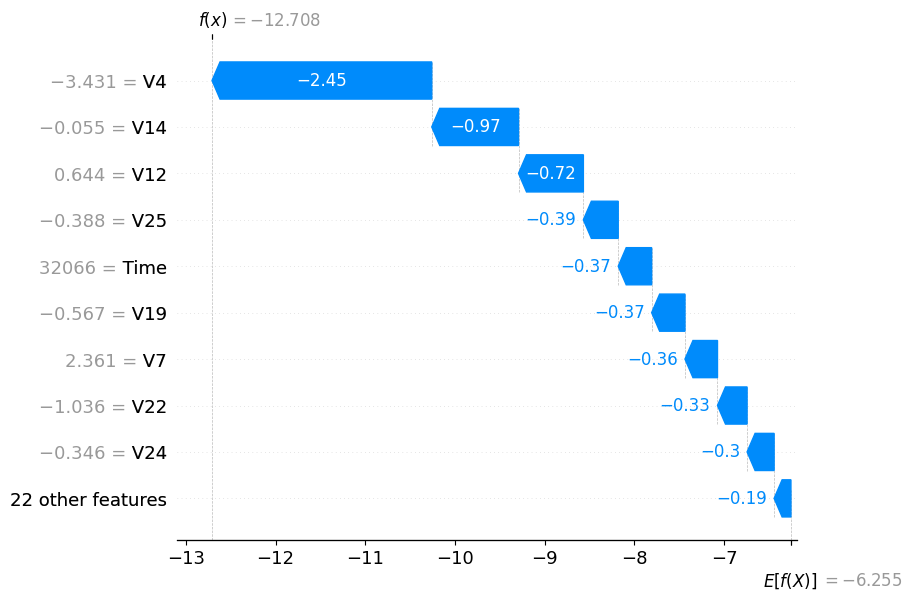

In [26]:
indice = 10

print("Índice da transação:", indice)
print("Classe real:", y_test.iloc[indice])
print("Probabilidade de fraude:", round(float(y_probs_xgb[indice]), 6))
print("Classe prevista:", int(y_pred_xgb[indice]))

shap.plots.waterfall(shap_values[indice])

# 15. Conclusões

A análise compara diferentes abordagens para detecção de fraude em um cenário altamente desbalanceado.

Os pontos principais:

- A accuracy não deve ser utilizada isoladamente (devido ao desbalanceamento entre as classes).
- Logistic Regression funciona como baseline e apresenta alto Recall, mas com maior quantidade de falsos positivos.
- Random Forest e XGBoost permitem comparar estratégias baseadas em árvores e diferentes formas de lidar com o desbalanceamento.
- Undersampling e SMOTE são aplicados somente ao conjunto de treinamento e avaliados no conjunto de teste original.
- O threshold de decisão influencia diretamente o equilíbrio entre Precision e Recall.
- ROC-AUC e Precision-Recall fornecem perspectivas complementares sobre o desempenho.
- SHAP permite observar tanto a importância global das variáveis quanto a contribuição das características para uma previsão individual.
- A escolha de um modelo para produção depende do custo relativo de falsos positivos e falsos negativos e deve ser feita considerando o contexto de negócio.

# 16. Evoluções em relação à abordagem apresentada

Além do fluxo inicial do desafio, este notebook foi ampliado com:

- análise exploratória e visualização da distribuição das classes;
- comparação de Logistic Regression, Random Forest e XGBoost;
- aplicação efetiva de undersampling;
- aplicação efetiva de SMOTE;
- comparação das estratégias de balanceamento;
- GridSearchCV;
- comparação por Precision, Recall, F1-score e ROC-AUC;
- curvas ROC e Precision-Recall;
- análise de diferentes thresholds de decisão;
- avaliação do threshold ajustado;
- SHAP para explicação global e individual das previsões.

# 17. Reprodutibilidade

Pré-requisitos:

- pandas
- numpy
- scikit-learn
- imbalanced-learn
- xgboost
- shap
- matplotlib
